In [4]:
# Install required libraries (run once)
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')



In [5]:
# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("✅ All libraries imported successfully!")



✅ All libraries imported successfully!


In [6]:
# Generate realistic student dataset
np.random.seed(42)
n_students = 1000

data = {
    'Student_ID': range(1, n_students + 1),
    'Study_Hours': np.random.normal(4, 2, n_students).clip(0, 12),
    'Attendance': np.random.normal(85, 10, n_students).clip(60, 100),
    'Previous_Marks': np.random.normal(75, 15, n_students).clip(30, 100),
    'Assignments': np.random.normal(80, 12, n_students).clip(40, 100),
    'Internal_Marks': np.random.normal(78, 14, n_students).clip(35, 100),
    'Family_Income': np.random.choice(['Low', 'Medium', 'High'], n_students),
    'Extracurricular': np.random.choice([0, 1], n_students, p=[0.6, 0.4])
}

df = pd.DataFrame(data)

# Create target variable (Pass/Fail)
df['Final_Score'] = (
    0.2 * df['Study_Hours'] * 10 +
    0.25 * df['Attendance'] +
    0.3 * df['Previous_Marks'] +
    0.15 * df['Assignments'] +
    0.1 * df['Internal_Marks']
)
df['Final_Score'] += np.random.normal(0, 8, n_students)
df['Final_Result'] = (df['Final_Score'] >= 70).astype(int)  # 1=Pass, 0=Fail

In [7]:
# Save dataset
df.to_csv('student_data.csv', index=False)

print("✅ Dataset created!")
print(f"📊 Shape: {df.shape}")
print("\n📋 First 5 rows:")
df.head()


✅ Dataset created!
📊 Shape: (1000, 10)

📋 First 5 rows:


,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Family_Income,Extracurricular,Final_Score,Final_Result
0,1,4.993428,98.993554,64.872326,57.106309,65.911090,Low,0,77.024529,1
1,2,3.723471,94.246337,72.832220,69.675380,77.563151,Medium,0,80.087305,1
2,3,5.295377,85.596304,63.113701,75.036734,78.252236,Low,1,54.425934,0
3,4,7.046060,78.530632,70.380577,100.000000,84.616825,Medium,1,86.128296,1
4,5,3.531693,91.982233,46.595780,86.678637,58.863983,High,0,56.441644,0


📈 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Student_ID       1000 non-null   int64  
 1   Study_Hours      1000 non-null   float64
 2   Attendance       1000 non-null   float64
 3   Previous_Marks   1000 non-null   float64
 4   Assignments      1000 non-null   float64
 5   Internal_Marks   1000 non-null   float64
 6   Family_Income    1000 non-null   object 
 7   Extracurricular  1000 non-null   int32  
 8   Final_Score      1000 non-null   float64
 9   Final_Result     1000 non-null   int32  
dtypes: float64(6), int32(2), int64(1), object(1)
memory usage: 70.4+ KB
None

📊 Descriptive Statistics:
        Student_ID  Study_Hours   Attendance  Previous_Marks  Assignments  \
count  1000.000000  1000.000000  1000.000000     1000.000000  1000.000000   
mean    500.500000     4.049278    85.396083       74.790356    79.

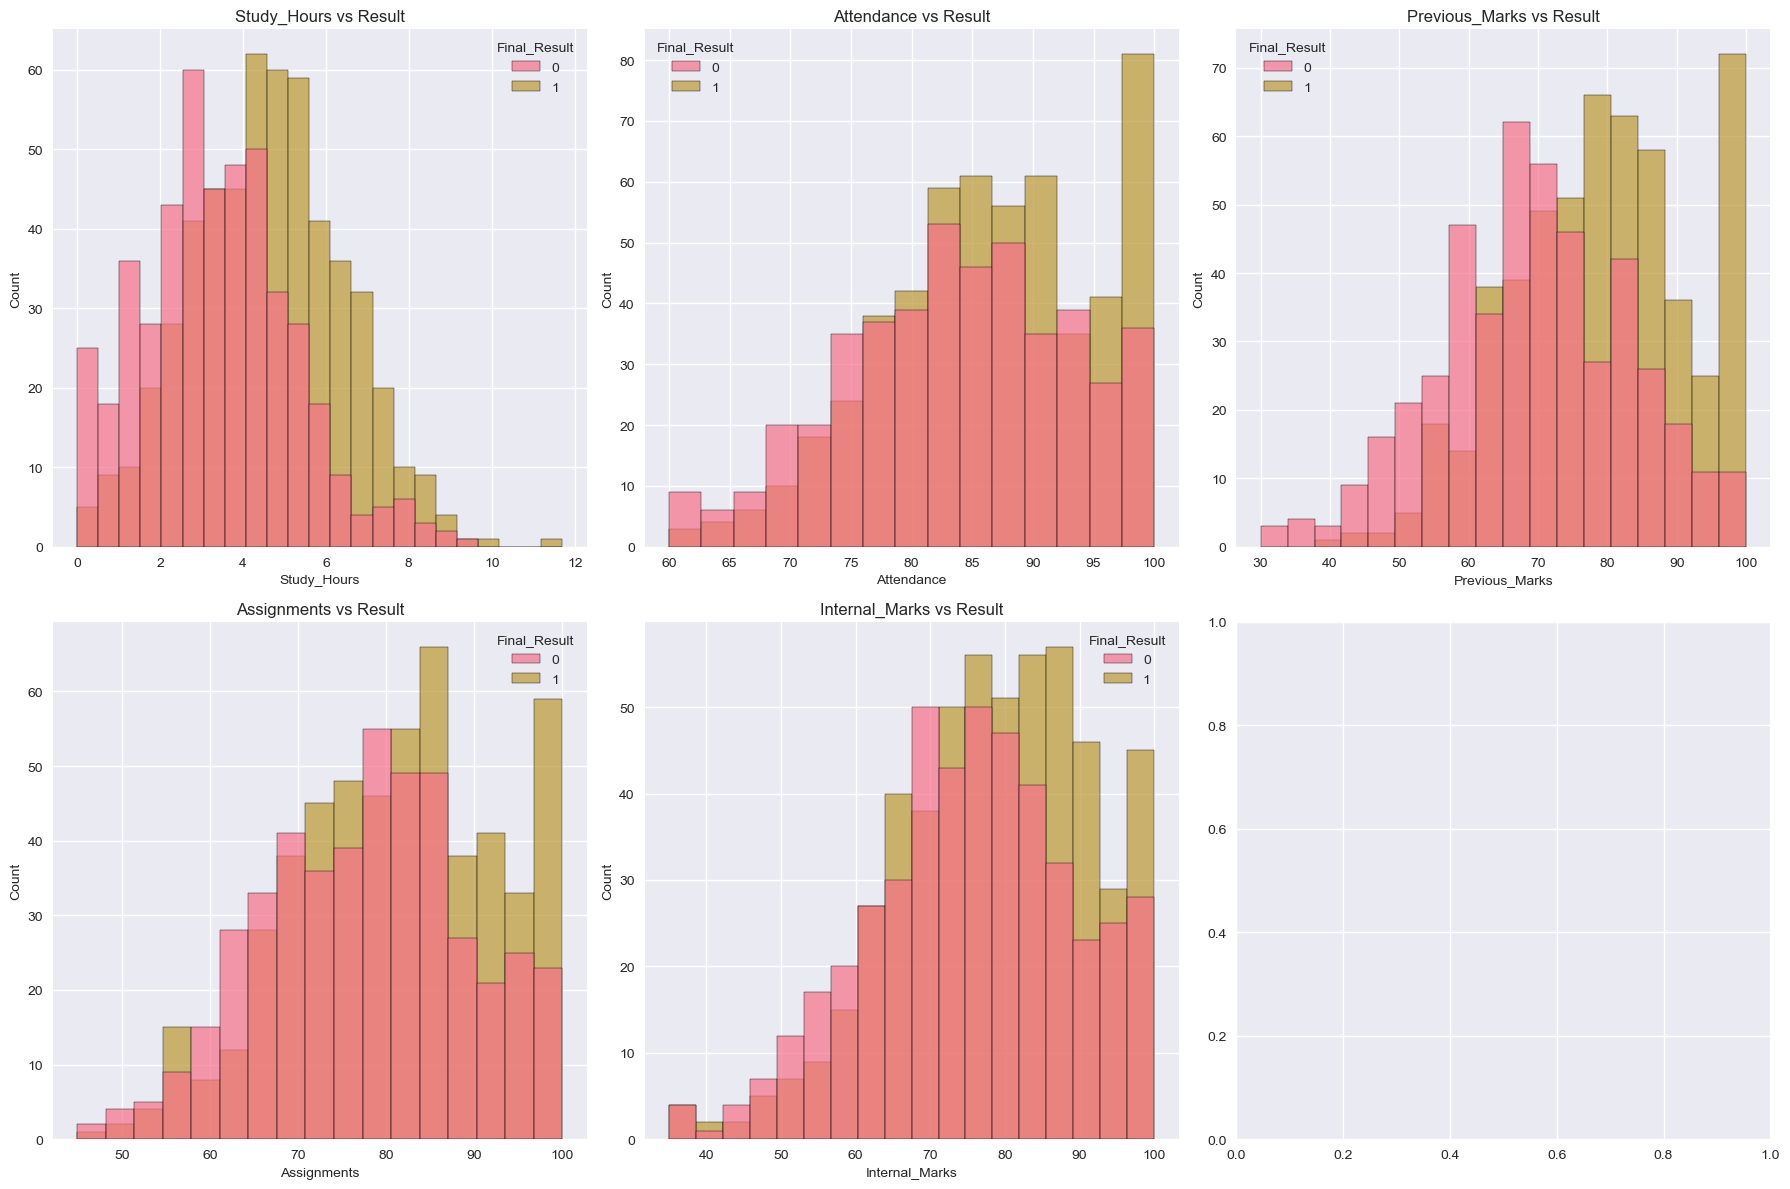

In [8]:
# Basic info
print("📈 Dataset Info:")
print(df.info())
print("\n📊 Descriptive Statistics:")
print(df.describe())

# Visualize distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
features = ['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 'Internal_Marks']

for i, feature in enumerate(features):
    row, col = i // 3, i % 3
    sns.histplot(data=df, x=feature, hue='Final_Result', ax=axes[row, col], alpha=0.7)
    axes[row, col].set_title(f'{feature} vs Result')

plt.tight_layout()
plt.show()


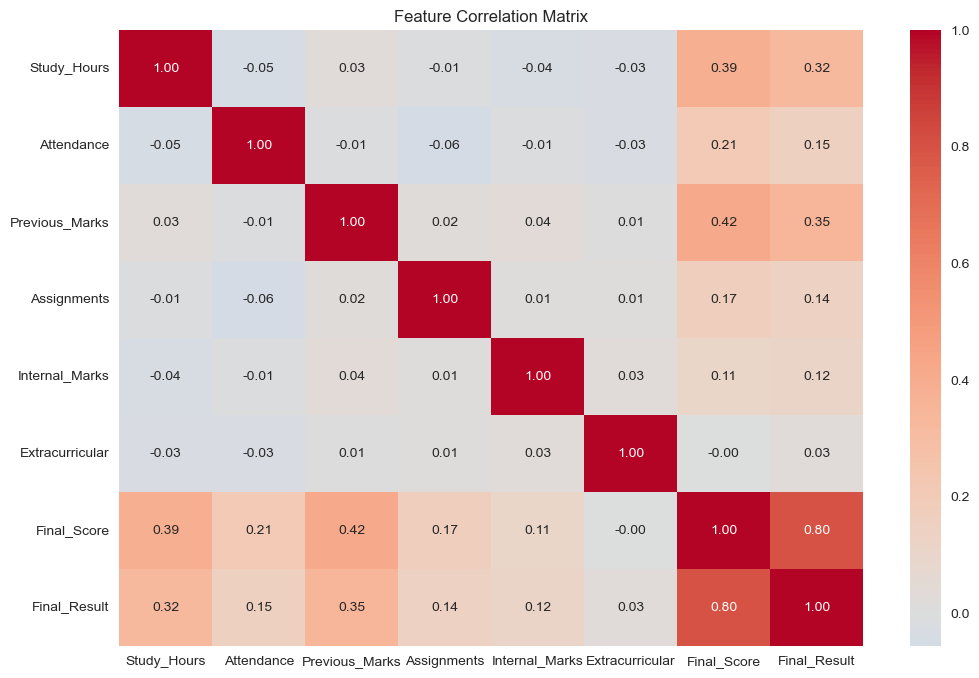

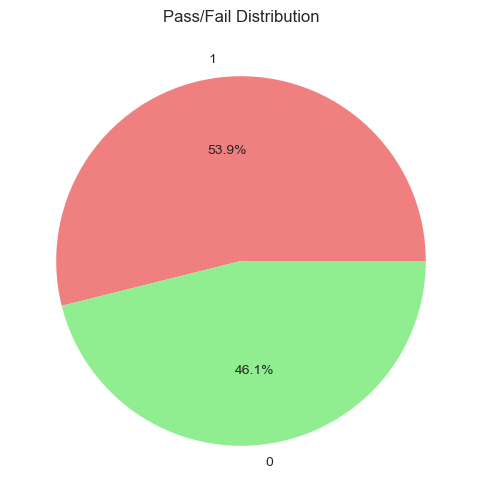

In [9]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Student_ID', errors='ignore')
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

# Pass/Fail distribution
plt.figure(figsize=(8, 6))
df['Final_Result'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
plt.title('Pass/Fail Distribution')
plt.ylabel('')
plt.show()


In [10]:
# Encode categorical variables
le_income = LabelEncoder()
df['Family_Income_Encoded'] = le_income.fit_transform(df['Family_Income'])

# Select features
features = ['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 
           'Internal_Marks', 'Family_Income_Encoded', 'Extracurricular']
X = df[features]
y = df['Final_Result']

print("✅ Features selected:")
print(features)
print(f"\nX shape: {X.shape}, y shape: {y.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Train: {X_train.shape}, Test: {X_test.shape}")
print(f"✅ Pass ratio (train): {y_train.mean():.2%}")

✅ Features selected:
['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 'Internal_Marks', 'Family_Income_Encoded', 'Extracurricular']

X shape: (1000, 7), y shape: (1000,)

✅ Train: (800, 7), Test: (200, 7)
✅ Pass ratio (train): 53.87%


In [11]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(random_state=42, probability=True)
}

# Train and evaluate
results = {}
for name, model in models.items():
    if name == 'SVM':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"{name:>18}: {accuracy:.4f}")

# Best model
best_model_name = max(results, key=results.get)
print(f"\n🏆 Best Model: {best_model_name} ({results[best_model_name]:.4f})")


Logistic Regression: 0.7000
     Decision Tree: 0.6150
     Random Forest: 0.7100
       Naive Bayes: 0.7050
               SVM: 0.7000

🏆 Best Model: Random Forest (0.7100)


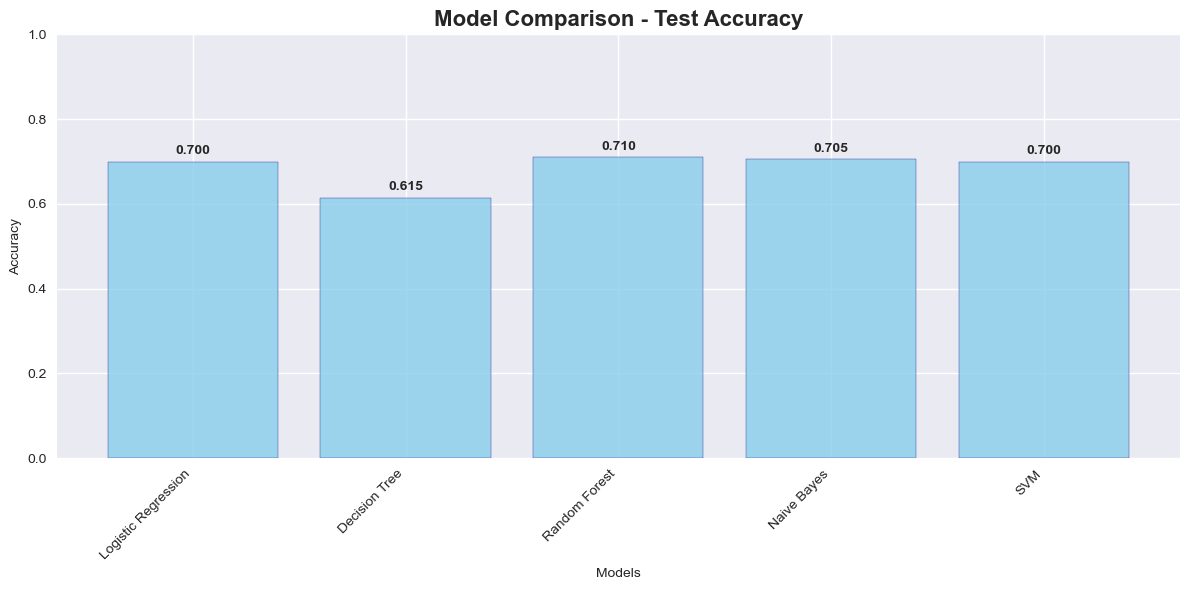

In [12]:
# Bar plot comparison
plt.figure(figsize=(12, 6))
model_names = list(results.keys())
accuracies = list(results.values())

bars = plt.bar(model_names, accuracies, color='skyblue', edgecolor='navy', alpha=0.8)
plt.title('Model Comparison - Test Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')

# Add value labels
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



📊 Random Forest Detailed Report:
              precision    recall  f1-score   support

           0       0.71      0.63      0.67        92
           1       0.71      0.78      0.74       108

    accuracy                           0.71       200
   macro avg       0.71      0.70      0.71       200
weighted avg       0.71      0.71      0.71       200



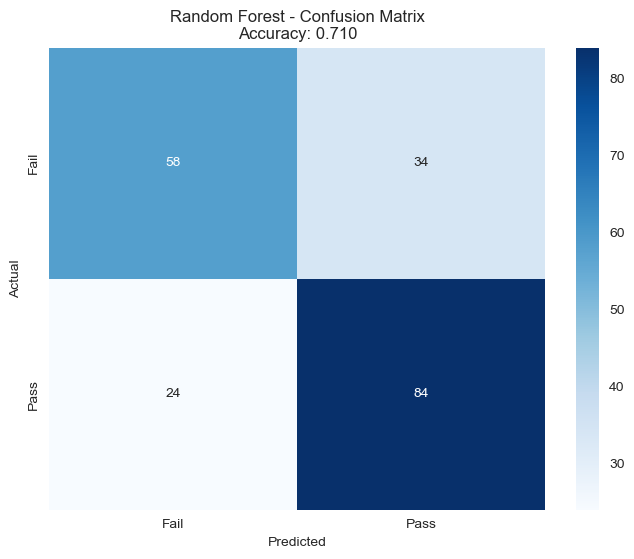

In [13]:
# Train best model completely
best_model = models[best_model_name]
if best_model_name == 'SVM':
    best_model.fit(X_train_scaled, y_train)
    y_pred_best = best_model.predict(X_test_scaled)
else:
    best_model.fit(X_train, y_train)
    y_pred_best = best_model.predict(X_test)

# Detailed metrics
print(f"\n📊 {best_model_name} Detailed Report:")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title(f'{best_model_name} - Confusion Matrix\nAccuracy: {accuracy_score(y_test, y_pred_best):.3f}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



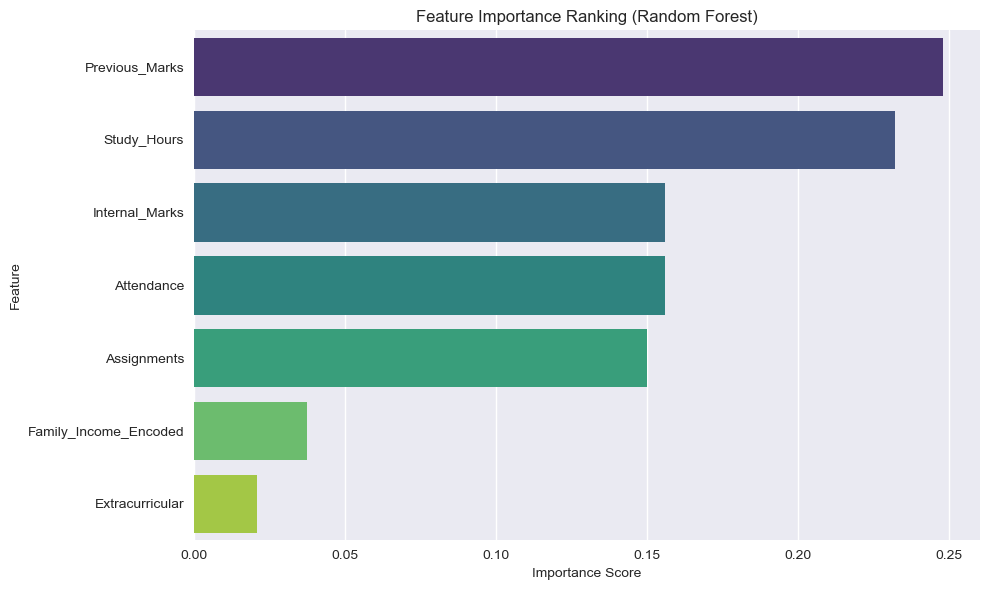

📊 Feature Importance:
                 Feature  Importance
2         Previous_Marks       0.248
0            Study_Hours       0.232
4         Internal_Marks       0.156
1             Attendance       0.156
3            Assignments       0.150
5  Family_Income_Encoded       0.037
6        Extracurricular       0.021


In [14]:
# Feature importance (Random Forest)
rf_model = models['Random Forest']
rf_model.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance Ranking (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("📊 Feature Importance:")
print(importance_df.round(3))


In [15]:
# Save the best trained model
joblib.dump(best_model, 'student_performance_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model and scaler saved successfully!")

✅ Model and scaler saved successfully!


In [16]:
# Predict new student performance

new_student = [[5, 90, 80, 85, 78, 1, 1]]
# Features:
# Study_Hours, Attendance, Previous_Marks,
# Assignments, Internal_Marks,
# Family_Income_Encoded, Extracurricular

if best_model_name == 'SVM':
    new_student = scaler.transform(new_student)
    prediction = best_model.predict(new_student)
else:
    prediction = best_model.predict(new_student)

result = "PASS" if prediction[0] == 1 else "FAIL"

print("\n🎯 Prediction for New Student:", result)


🎯 Prediction for New Student: PASS


In [17]:
print("\n📊 Final Model Accuracies:")
for model, score in results.items():
    print(f"{model}: {score*100:.2f}%")


📊 Final Model Accuracies:
Logistic Regression: 70.00%
Decision Tree: 61.50%
Random Forest: 71.00%
Naive Bayes: 70.50%
SVM: 70.00%
